# 📊 Marketing Campaign Analytics: A/B Testing & Conversion Optimization  
**SQL | Python | Power BI | Statistics**
### *Optimizing Spend and Predicting Conversions across Facebook & Instagram*

### **Project Overview:** This analysis evaluates 900+ days of advertising data across Facebook and Instagram. By leveraging SQL for data normalization, Statistical A/B Testing, and Linear Regression, we aim to identify the most scalable and cost-efficient growth engine for the brand.

### **Business Problem**
### ```How can we optimize our cross-channel marketing budget between Facebook and Instagram to maximize conversion volume while maintaining the lowest possible Cost Per Acquisition (CPA)?```

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [2]:
df = pd.read_csv('/content/marketing_campaign.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          1000 non-null   object 
 1   Facebook Ad Campaign          1000 non-null   object 
 2   Instagram Ad Campaign         1000 non-null   object 
 3   Facebook Ad Views             965 non-null    float64
 4   Instagram Ad Views            973 non-null    float64
 5   Facebook Click-through Rate   1000 non-null   float64
 6   Instagram Click-through Rate  1000 non-null   float64
 7   Facebook Ad Clicks            938 non-null    float64
 8   Instagram Ad Clicks           941 non-null    float64
 9   Facebook Conversion Rate      1000 non-null   float64
 10  Instagram Conversion Rate     1000 non-null   float64
 11  Facebook Ad Conversion        931 non-null    float64
 12  Instagram Ad Conversion       947 non-null    float64
 13  Cost

In [3]:
df.isnull().sum()

,0
Date,0
Facebook Ad Campaign,0
Instagram Ad Campaign,0
Facebook Ad Views,35
Instagram Ad Views,27
Facebook Click-through Rate,0
Instagram Click-through Rate,0
Facebook Ad Clicks,62
Instagram Ad Clicks,59
Facebook Conversion Rate,0


In [4]:
df.dtypes

,0
Date,object
Facebook Ad Campaign,object
Instagram Ad Campaign,object
Facebook Ad Views,float64
Instagram Ad Views,float64
Facebook Click-through Rate,float64
Instagram Click-through Rate,float64
Facebook Ad Clicks,float64
Instagram Ad Clicks,float64
Facebook Conversion Rate,float64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Facebook Ad Views,965.0,16121.700518,6521.625764,5011.000000,10724.000000,16048.000000,21087.000000,32397.000000
Instagram Ad Views,973.0,14047.469681,5894.025424,4025.000000,9185.000000,13834.000000,18631.000000,28563.000000
Facebook Click-through Rate,1000.0,0.045409,0.013658,0.020013,0.035329,0.045991,0.056136,0.069923
Instagram Click-through Rate,1000.0,0.040817,0.012250,0.018005,0.031514,0.040106,0.049676,0.064931
Facebook Ad Clicks,938.0,732.384861,378.741783,103.000000,428.250000,664.500000,956.750000,2200.000000
Instagram Ad Clicks,941.0,568.896918,301.712522,83.000000,333.000000,521.000000,756.000000,1830.000000
Facebook Conversion Rate,1000.0,0.091084,0.027798,0.040247,0.071022,0.091735,0.113697,0.139974
Instagram Conversion Rate,1000.0,0.079720,0.027198,0.030010,0.059957,0.079993,0.099286,0.129978
Facebook Ad Conversion,931.0,70.252417,51.247194,5.000000,30.000000,57.000000,97.000000,283.000000
Instagram Ad Conversion,947.0,48.669483,36.624856,2.000000,21.000000,38.000000,68.000000,213.000000


- Checking skewness of data

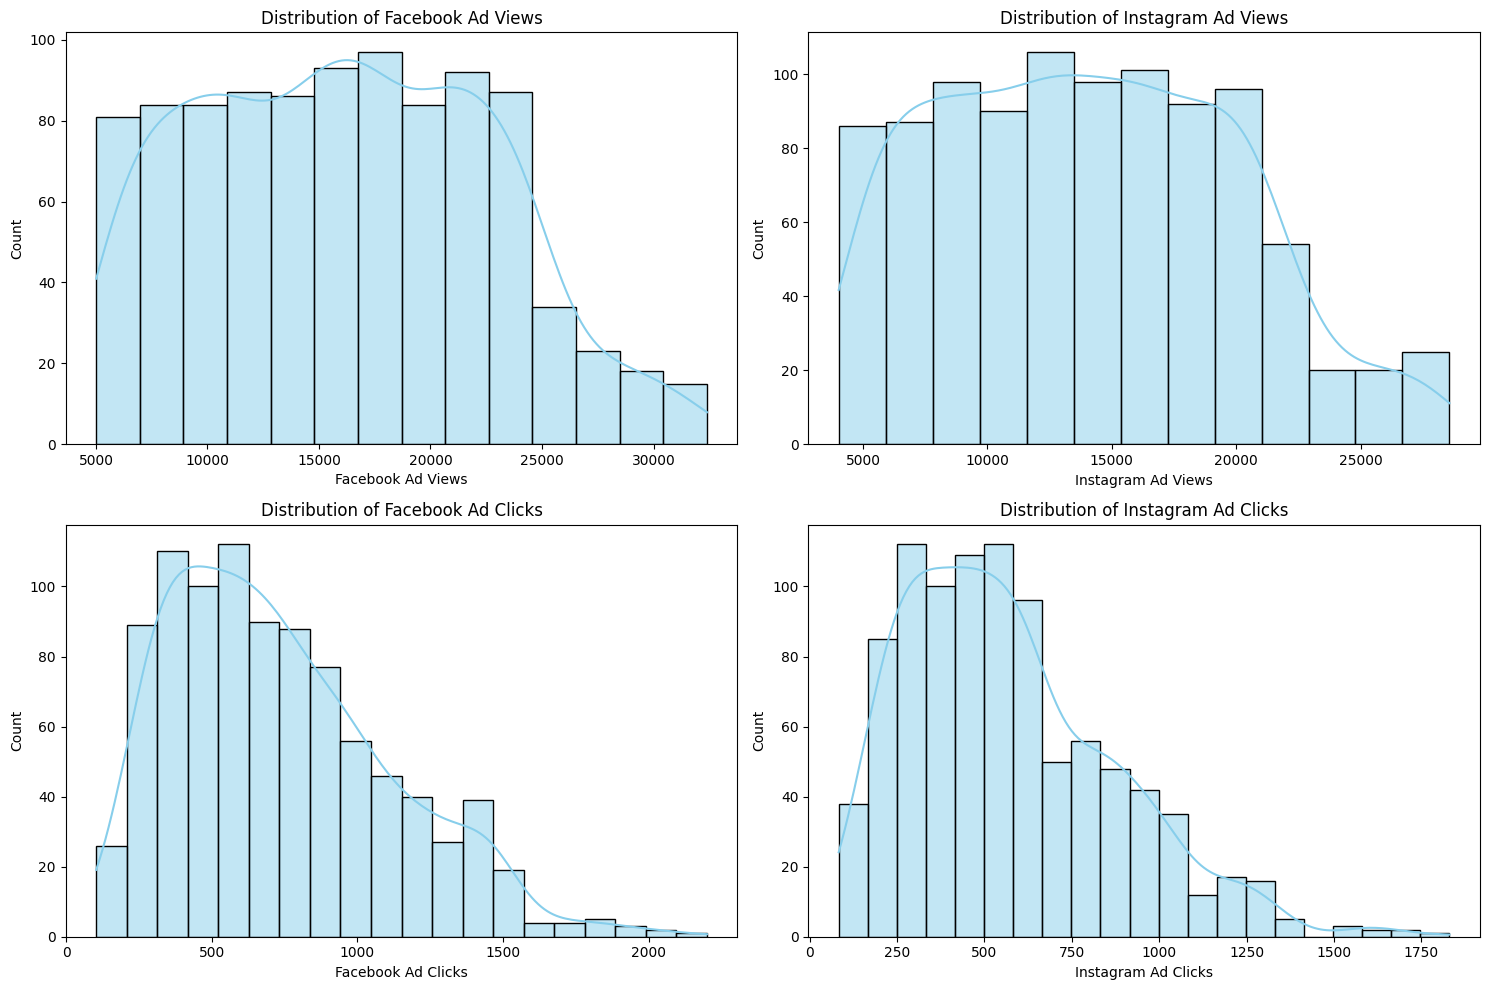

In [6]:
#Distributions of Key Metrics
metrics_to_plot = ['Facebook Ad Views', 'Instagram Ad Views', 'Facebook Ad Clicks', 'Instagram Ad Clicks']

plt.figure(figsize=(15, 10))
for i, col in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df = df.dropna(subset = ['Facebook Ad Views', 'Instagram Ad Views'])

In [9]:
df['Facebook Ad Clicks'] = df['Facebook Ad Clicks'].fillna(df['Facebook Ad Clicks'].median())
df['Facebook Ad Conversion'] = df['Facebook Ad Conversion'].fillna(df['Instagram Ad Conversion'].median())

In [10]:
df['Instagram Ad Clicks'] = df['Instagram Ad Clicks'].fillna(df['Instagram Ad Clicks'].median())
df['Instagram Ad Conversion'] = df['Instagram Ad Conversion'].fillna(df['Instagram Ad Conversion'].median())

In [11]:
# checking consistency of funnel
consistency_checks = {
    "FB: Clicks > Views": df[df['Facebook Ad Clicks'] > df['Facebook Ad Views']].shape[0],
    "IG: Clicks > Views": df[df['Instagram Ad Clicks'] > df['Instagram Ad Views']].shape[0],
    "FB: Conversions > Clicks": df[df['Facebook Ad Conversion'] > df['Facebook Ad Clicks']].shape[0],
    "IG: Conversions > Clicks": df[df['Instagram Ad Conversion'] > df['Instagram Ad Clicks']].shape[0]
}
consistency_checks

{'FB: Clicks > Views': 0,
 'IG: Clicks > Views': 0,
 'FB: Conversions > Clicks': 0,
 'IG: Conversions > Clicks': 0}

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 939 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date                          939 non-null    datetime64[ns]
 1   Facebook Ad Campaign          939 non-null    object        
 2   Instagram Ad Campaign         939 non-null    object        
 3   Facebook Ad Views             939 non-null    float64       
 4   Instagram Ad Views            939 non-null    float64       
 5   Facebook Click-through Rate   939 non-null    float64       
 6   Instagram Click-through Rate  939 non-null    float64       
 7   Facebook Ad Clicks            939 non-null    float64       
 8   Instagram Ad Clicks           939 non-null    float64       
 9   Facebook Conversion Rate      939 non-null    float64       
 10  Instagram Conversion Rate     939 non-null    float64       
 11  Facebook Ad Conversion        939 non

In [13]:
int_cols = ['Facebook Ad Views', 'Instagram Ad Views',
            'Facebook Ad Clicks', 'Instagram Ad Clicks',
            'Facebook Ad Conversion', 'Instagram Ad Conversion']

df[int_cols] = df[int_cols].astype(int)
df.dtypes

,0
Date,datetime64[ns]
Facebook Ad Campaign,object
Instagram Ad Campaign,object
Facebook Ad Views,int64
Instagram Ad Views,int64
Facebook Click-through Rate,float64
Instagram Click-through Rate,float64
Facebook Ad Clicks,int64
Instagram Ad Clicks,int64
Facebook Conversion Rate,float64


#### Feature Engineering
- Creating Helper Columns

In [14]:
df['Total Spend'] = df['Cost Per Facebook Ad'] + df['Cost Per Instagram Ad']
df['Total Clicks'] = df['Facebook Ad Clicks'] + df['Instagram Ad Clicks']
df['Total Conversions'] = df['Facebook Ad Conversion'] + df['Instagram Ad Conversion']

In [15]:
df['Overall CTR'] = (df['Total Clicks'] / (df['Facebook Ad Views'] + df['Instagram Ad Views'])) * 100
df['Overall Conversion Rate'] = (df['Total Conversions'] / df['Total Clicks']) * 100
df['Overall Cost Per Click'] = df['Total Spend'] / df['Total Clicks']
df['Overall Cost Per Conversion'] = df['Total Spend'] / df['Total Conversions']


In [16]:
df['FB Click-though %'] = df['Facebook Click-through Rate']*100
df['IG Click-though %'] = df['Instagram Click-through Rate']*100

In [17]:
df.head()

,Date,Facebook Ad Campaign,Instagram Ad Campaign,Facebook Ad Views,Instagram Ad Views,Facebook Click-through Rate,Instagram Click-through Rate,Facebook Ad Clicks,Instagram Ad Clicks,Facebook Conversion Rate,...,Instagram Cost Per Click,Total Spend,Total Clicks,Total Conversions,Overall CTR,Overall Conversion Rate,Overall Cost Per Click,Overall Cost Per Conversion,FB Click-though %,IG Click-though %
0,2024-01-01,FB_C,IG_Z,24811,15101,0.023771,0.024639,589,372,0.041806,...,0.762922,721.250868,961,38,2.407797,3.954214,0.750521,18.980286,2.377081,2.463943
1,2024-01-02,FB_A,IG_Z,9780,11950,0.063449,0.027307,620,326,0.117516,...,0.912129,1064.289749,946,91,4.353428,9.619450,1.125042,11.695492,6.344921,2.730674
2,2024-01-03,FB_C,IG_Z,23311,13122,0.039540,0.018274,921,239,0.073760,...,0.583216,999.813121,1160,74,3.183927,6.379310,0.861908,13.510988,3.954014,1.827365
3,2024-01-04,FB_C,IG_Z,16894,16576,0.022038,0.019632,372,325,0.050496,...,0.626421,433.283489,697,38,2.082462,5.451937,0.621641,11.402197,2.203786,1.963197
4,2024-01-05,FB_A,IG_X,7356,5089,0.050166,0.050172,369,255,0.116869,...,1.076302,678.384054,624,67,5.014062,10.737179,1.087154,10.125135,5.016640,5.017183


- Using SQL to Answer Business Questions

In [18]:
import sqlite3

conn = sqlite3.connect('marketing.db')

df.to_sql('marketing_data', conn, if_exists='replace', index=False)


939

In [19]:
pd.read_sql_query("""select * from marketing_data limit 5""", conn)

,Date,Facebook Ad Campaign,Instagram Ad Campaign,Facebook Ad Views,Instagram Ad Views,Facebook Click-through Rate,Instagram Click-through Rate,Facebook Ad Clicks,Instagram Ad Clicks,Facebook Conversion Rate,...,Instagram Cost Per Click,Total Spend,Total Clicks,Total Conversions,Overall CTR,Overall Conversion Rate,Overall Cost Per Click,Overall Cost Per Conversion,FB Click-though %,IG Click-though %
0,2024-01-01 00:00:00,FB_C,IG_Z,24811,15101,0.023771,0.024639,589,372,0.041806,...,0.762922,721.250868,961,38,2.407797,3.954214,0.750521,18.980286,2.377081,2.463943
1,2024-01-02 00:00:00,FB_A,IG_Z,9780,11950,0.063449,0.027307,620,326,0.117516,...,0.912129,1064.289749,946,91,4.353428,9.619450,1.125042,11.695492,6.344921,2.730674
2,2024-01-03 00:00:00,FB_C,IG_Z,23311,13122,0.039540,0.018274,921,239,0.073760,...,0.583216,999.813121,1160,74,3.183927,6.379310,0.861908,13.510988,3.954014,1.827365
3,2024-01-04 00:00:00,FB_C,IG_Z,16894,16576,0.022038,0.019632,372,325,0.050496,...,0.626421,433.283489,697,38,2.082462,5.451937,0.621641,11.402197,2.203786,1.963197
4,2024-01-05 00:00:00,FB_A,IG_X,7356,5089,0.050166,0.050172,369,255,0.116869,...,1.076302,678.384054,624,67,5.014062,10.737179,1.087154,10.125135,5.016640,5.017183


- Campaign Performance

In [33]:
query = """
SELECT
    campaign,
    SUM(views) AS total_views,
    SUM(clicks) AS total_clicks,
    SUM(conversions) AS total_conversions,
    SUM(cost) AS total_cost
FROM (
    SELECT
        "Facebook Ad Campaign" AS campaign,
        "Facebook Ad Views" AS views,
        "Facebook Ad Clicks" AS clicks,
        "Facebook Ad Conversion" AS conversions,
        "Cost Per Facebook Ad" AS cost
    FROM marketing_data

    UNION ALL

    SELECT
        "Instagram Ad Campaign",
        "Instagram Ad Views",
        "Instagram Ad Clicks",
        "Instagram Ad Conversion",
        "Cost Per Instagram Ad"
    FROM marketing_data
)
GROUP BY campaign
ORDER BY total_conversions DESC;
"""

pd.read_sql(query, conn)

,campaign,total_views,total_clicks,total_conversions,total_cost
0,FB_A,5371173,320915,37688,380079.672862
1,IG_X,4351570,235394,25607,259114.716463
2,FB_B,4755547,212371,18487,212324.601000
3,IG_Y,4375889,173056,13737,164195.037490
4,FB_C,4957113,149950,8641,117655.653140
5,IG_Z,4426084,124685,6184,91816.446787


- Platform Comparision (FB vs IG)

In [26]:
query = """
select
'Facebook' as Platform,
sum("Facebook Ad Views") as Total_Views,
sum("Facebook Ad Clicks") as Total_Clicks,
sum("Facebook Ad Conversion") as Total_Conversions,
sum("Cost Per Facebook Ad") as Total_Cost
from marketing_data

union all

select
'Instagram' as Platform,
sum("Instagram Ad Views") as Total_Views,
sum("Instagram Ad Clicks") as Total_Clicks,
sum("Instagram Ad Conversion") as Total_Conversions,
sum("Cost Per Instagram Ad") as Total_Cost
from marketing_data
"""

pd.read_sql(query, conn)

,Platform,Total_Views,Total_Clicks,Total_Conversions,Total_Cost
0,Facebook,15083833,683236,64816,710059.927003
1,Instagram,13153543,533135,45528,515126.200741


- Campaign Efficiency

In [34]:
query = """
SELECT
    campaign,
    AVG(ctr) AS avg_ctr,
    AVG(conv_rate) AS avg_conversion_rate,
    AVG(cpc) AS avg_cpc
FROM (
    SELECT
        "Facebook Ad Campaign" AS campaign,
        "Facebook Click-through Rate" AS ctr,
        "Facebook Conversion Rate" AS conv_rate,
        "Facebook Cost Per Click" AS cpc
    FROM marketing_data

    UNION ALL

    SELECT
        "Instagram Ad Campaign",
        "Instagram Click-through Rate",
        "Instagram Conversion Rate",
        "Instagram Cost Per Click"
    FROM marketing_data
)
GROUP BY campaign;
"""
pd.read_sql_query(query, conn)

,campaign,avg_ctr,avg_conversion_rate,avg_cpc
0,FB_A,0.059998,0.121185,1.180886
1,FB_B,0.044571,0.089459,1.000654
2,FB_C,0.029841,0.059476,0.801437
3,IG_X,0.054472,0.109973,1.089174
4,IG_Y,0.039896,0.079581,0.944399
5,IG_Z,0.028042,0.049802,0.743557


- Unified Campaign Performance (Weighted Aggregation)

In [51]:
query = """
SELECT
    campaign,
    SUM(clicks) * 100.0 / SUM(views) AS campaign_ctr,
    SUM(conversions) * 100.0 / SUM(clicks) AS campaign_conversion_rate,
    SUM(cost) * 1.0 / SUM(conversions) AS campaign_cost_per_conversion,
    SUM(cost) AS total_spend,
    SUM(conversions) AS total_conversions
FROM (
    SELECT
        "Facebook Ad Campaign" AS campaign,
        "Facebook Ad Views" AS views,
        "Facebook Ad Clicks" AS clicks,
        "Facebook Ad Conversion" AS conversions,
        "Cost Per Facebook Ad" AS cost
    FROM marketing_data

    UNION ALL

    SELECT
        "Instagram Ad Campaign",
        "Instagram Ad Views",
        "Instagram Ad Clicks",
        "Instagram Ad Conversion",
        "Cost Per Instagram Ad"
    FROM marketing_data
)
GROUP BY campaign
ORDER BY total_conversions DESC;
"""

pd.read_sql_query(query, conn)

,campaign,campaign_ctr,campaign_conversion_rate,campaign_cost_per_conversion,total_spend,total_conversions
0,FB_A,5.974766,11.743920,10.084899,380079.672862,37688
1,IG_X,5.409404,10.878357,10.118902,259114.716463,25607
2,FB_B,4.465753,8.705049,11.485076,212324.601000,18487
3,IG_Y,3.954762,7.937893,11.952758,164195.037490,13737
4,FB_C,3.024946,5.762588,13.615977,117655.653140,8641
5,IG_Z,2.817050,4.959698,14.847420,91816.446787,6184


#### EDA
- Relationship Between Ad spend and Conversions

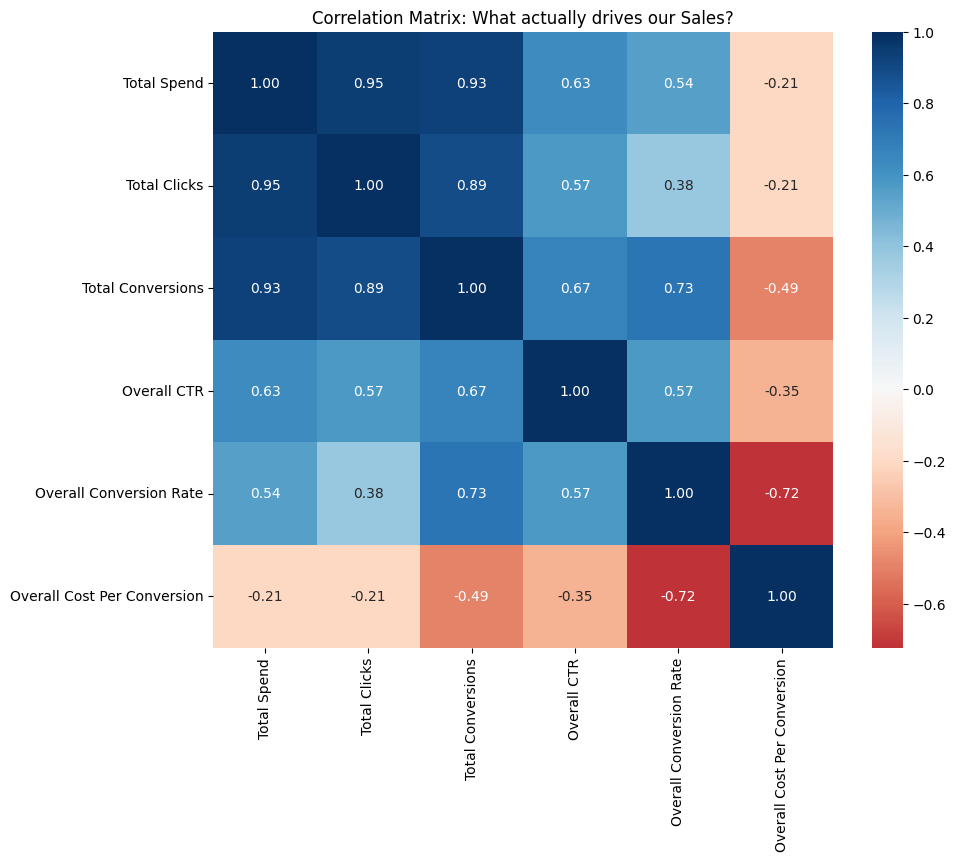

In [54]:
corr_cols = [
    'Total Spend', 'Total Clicks', 'Total Conversions',
    'Overall CTR', 'Overall Conversion Rate', 'Overall Cost Per Conversion']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdBu', fmt=".2f", center=0)
plt.title("Correlation Matrix: What actually drives our Sales?")
plt.show()

- Total Spend and Total COnversions has strong correlation 0.93 which suggest Ads are scalable
- Overall CTR% and Total Conversions has 0.67 correlation which suggests people are clicking Ads but not buying

#### Identifying Money Wasters and Outliers

In [57]:
df.columns.to_list()

['Date',
 'Facebook Ad Campaign',
 'Instagram Ad Campaign',
 'Facebook Ad Views',
 'Instagram Ad Views',
 'Facebook Click-through Rate',
 'Instagram Click-through Rate',
 'Facebook Ad Clicks',
 'Instagram Ad Clicks',
 'Facebook Conversion Rate',
 'Instagram Conversion Rate',
 'Facebook Ad Conversion',
 'Instagram Ad Conversion',
 'Cost Per Facebook Ad',
 'Cost Per Instagram Ad',
 'Facebook Cost Per Click',
 'Instagram Cost Per Click',
 'Total Spend',
 'Total Clicks',
 'Total Conversions',
 'Overall CTR',
 'Overall Conversion Rate',
 'Overall Cost Per Click',
 'Overall Cost Per Conversion',
 'FB Click-though %',
 'IG Click-though %']

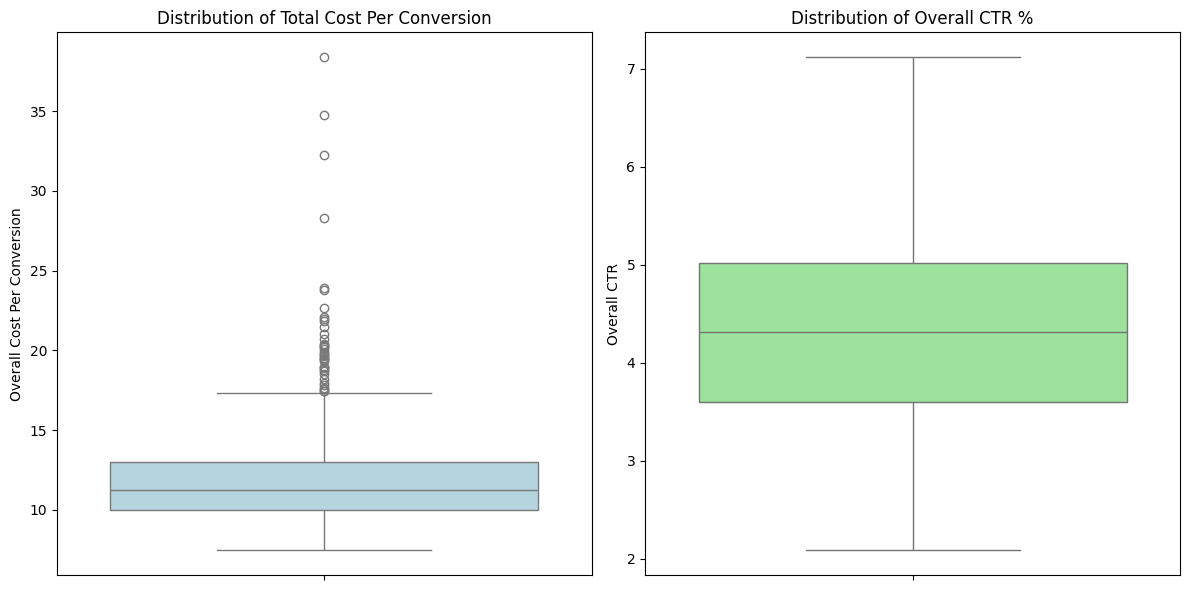

In [59]:
plt.figure(figsize=(12, 6))

# Comparing the spread of Cost Per Conversion between FB and IG
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='Overall Cost Per Conversion', color='lightblue')
plt.title("Distribution of Total Cost Per Conversion")

# Identifying days where CTR was unusually high/low
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='Overall CTR', color='lightgreen')
plt.title("Distribution of Overall CTR %")

plt.tight_layout()
plt.show()

- Cost per Conversion chart has many outliers which suggests Cost Per conversion varies a lot, mean Cost per conversion is around 9-14 but some day cost per conversion has gone upto 35+
- Overall CTR has no Outliers which suggest almost everyday Overall CTR was around same range

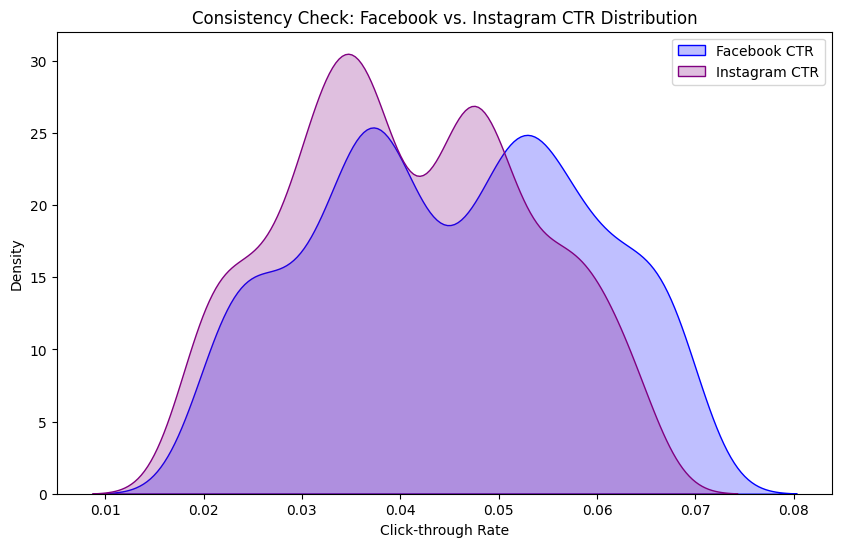

In [67]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Facebook Click-through Rate'], fill=True, label='Facebook CTR', color='blue')
sns.kdeplot(df['Instagram Click-through Rate'], fill=True, label='Instagram CTR', color='purple')
plt.title("Consistency Check: Facebook vs. Instagram CTR Distribution")
plt.xlabel("Click-through Rate")
plt.legend()
plt.show()

#### Interpretation
- Instagram appears to deliver more consistent CTRs within its two primary performance bands (around 3% and 5%). Facebook, while potentially having more varied performance, demonstrates a higher ceiling for CTR, with some ads achieving significantly higher engagement rates (up to 8%) compared to Instagram's maximum observed CTR (around 7%). This suggests different strengths for each platform, with Instagram being good for predictable engagement and Facebook offering the potential for higher-impact, albeit possibly less consistent, ad performance.

In [71]:
df.columns.to_list()

['Date',
 'Facebook Ad Campaign',
 'Instagram Ad Campaign',
 'Facebook Ad Views',
 'Instagram Ad Views',
 'Facebook Click-through Rate',
 'Instagram Click-through Rate',
 'Facebook Ad Clicks',
 'Instagram Ad Clicks',
 'Facebook Conversion Rate',
 'Instagram Conversion Rate',
 'Facebook Ad Conversion',
 'Instagram Ad Conversion',
 'Cost Per Facebook Ad',
 'Cost Per Instagram Ad',
 'Facebook Cost Per Click',
 'Instagram Cost Per Click',
 'Total Spend',
 'Total Clicks',
 'Total Conversions',
 'Overall CTR',
 'Overall Conversion Rate',
 'Overall Cost Per Click',
 'Overall Cost Per Conversion',
 'FB Click-though %',
 'IG Click-though %']

#### If the difference between Facebook and Instagram is Statistically Significant or just a result of random luck.
```
Using Two-Sample T-Test on the CTR of both platforms
```

In [74]:
# two groups
fb_ctr = df['FB Click-though %']
ig_ctr = df['IG Click-though %']

t_stat, p_value = stats.ttest_ind(fb_ctr, ig_ctr)

# 3. Output the results
print("--- A/B Testing: Facebook vs Instagram CTR ---")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

# 4. The Decision Logic
alpha = 0.05 # Standard 95% confidence level
if p_value < alpha:
    print("\n✅ RESULT: Statistically Significant!")
    print("There is a REAL difference in how users interact with these platforms.")
else:
    print("\n❌ RESULT: Not Significant.")
    print("The difference we see is likely due to random noise.")

--- A/B Testing: Facebook vs Instagram CTR ---
T-Statistic: 7.4002
P-Value: 0.0000000000

✅ RESULT: Statistically Significant!
There is a REAL difference in how users interact with these platforms.


- Interpretation: The higher engagement on Facebook isn't just a lucky week; it's a consistent trend. We should analyze why Facebook ads are resonating more

### Regression Analysis (Predicting Conversions)
### - Does more engagement actually lead to more sales?
```
Regression Analysis (Predicting Conversions)
```

In [76]:
import statsmodels.api as sm
# If Clicks (X) predict Conversions (y)
X = df['Total Clicks']
y = df['Total Conversions']


# Baseline conversions if clicks were zero
X = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X).fit()

# 4. Print the Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Total Conversions   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     3572.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          6.08e-322
Time:                        13:17:55   Log-Likelihood:                -4482.9
No. Observations:                 939   AIC:                             8970.
Df Residuals:                     937   BIC:                             8980.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -33.0102      2.687    -12.286   

The regression analysis indicates a very strong and statistically significant positive relationship between `Total Clicks` and `Total Conversions` (R-squared = 0.792). This means that approximately 79.2% of the variation in conversions can be explained by the number of clicks, with each additional click leading to roughly 0.116 (or 11.6%) of a conversion.

| Metric | Value | Interpretation |
|--------|-------|----------------|
| R-squared | 0.792 | High Accuracy: 79.2% of the variance in Conversions is explained by Clicks. |
| Coefficient (Clicks) | 0.1162 | Efficiency: Every 100 clicks generates approximately 11.6 conversions. |
| P-Value (Clicks) | 0.000 | Significant: The relationship is real and not due to random chance (p < 0.05). |

---

## Final Business Insights

- Platform Winner `(A/B Test)`: Facebook is the engagement king. With a statistically significant higher CTR **(T-stat: 7.4)**, Facebook is the better platform for brand awareness and driving traffic.

- The Profitability Gap: While Facebook has higher engagement, we saw "Bleed Days" in our CPA boxplots where costs spiked to **\$35+**.  We need to implement automated bid caps to stop spending when the Cost Per Conversion exceeds **\$20**.

- Budget Allocation `(Regression)`: Since Clicks directly drive **79%** of our sales, we should move **20%** of the Instagram budget to Facebook to take advantage of the higher CTR, which will theoretically yield more total conversions at the same cost

---

## The Executive Summary Dashboard

/tmp/ipykernel_17934/3935040537.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='campaign', y='CPA', data=summary_df, palette='viridis')


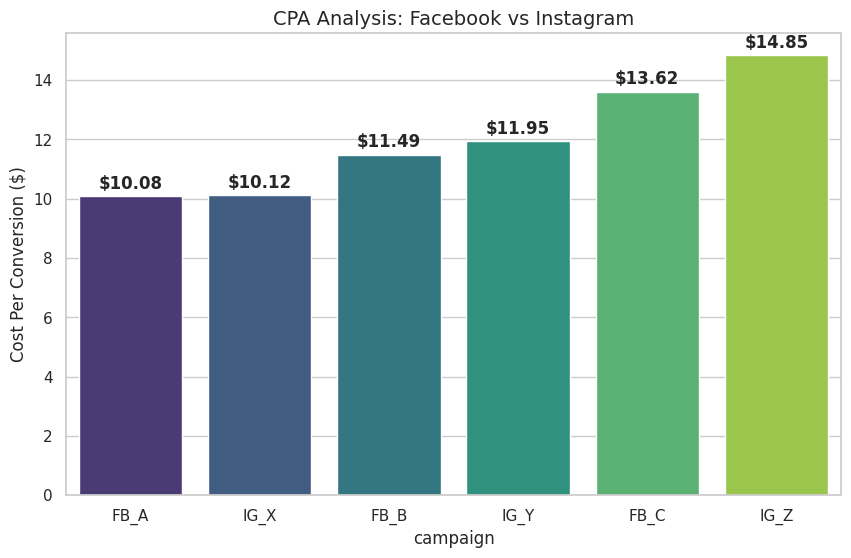

In [86]:
summary_df = pd.read_sql_query(query, conn)

summary_df['CPA'] = summary_df['total_spend'] / summary_df['total_conversions']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='campaign', y='CPA', data=summary_df, palette='viridis')

for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold')

plt.title('CPA Analysis: Facebook vs Instagram', fontsize=14)
plt.ylabel('Cost Per Conversion ($)')
plt.show()

- Interpretation: Overall Facebook Campaign is performing better than Instagram, although one Facebook  Campaigm `FB_C` has Higher CPA than others, we can pause  `IG_Z` Campaign and can do some neessary changes before continuing `FB_C` campaign

## Comprehensive Analysis Summary

This project aimed to optimize cross-channel marketing budget between Facebook and Instagram to maximize conversion volume while maintaining the lowest possible Cost Per Acquisition (CPA). We analyzed over 900 days of advertising data, leveraging data cleaning, feature engineering, SQL queries, statistical A/B testing, linear regression, and various visualizations.

### 1. Data Overview and Preprocessing

*   **Initial Data:** The dataset contained 1000 entries across 17 columns, including ad views, clicks, conversion rates, and costs for both Facebook and Instagram campaigns.
*   **Missing Values:** We identified and handled missing data. Specifically, rows with missing 'Facebook Ad Views' or 'Instagram Ad Views' were dropped (reducing the dataset to 939 entries), and missing 'Facebook Ad Clicks', 'Instagram Ad Clicks', 'Facebook Ad Conversion', and 'Instagram Ad Conversion' were imputed using their respective medians. This ensures a robust dataset for analysis.
*   **Data Types:** The 'Date' column was converted to datetime objects, and key numerical columns like 'Facebook Ad Views', 'Instagram Ad Views', 'Facebook Ad Clicks', 'Instagram Ad Clicks', 'Facebook Ad Conversion', and 'Instagram Ad Conversion' were converted to integer types for consistency and clarity.
*   **Consistency Checks:** We performed checks to ensure logical data integrity, such as verifying that ad clicks do not exceed ad views and conversions do not exceed clicks. All checks passed, indicating a clean data funnel.

### 2. Feature Engineering

To gain deeper insights, several new features were engineered:
*   **Total Spend:** Sum of costs for Facebook and Instagram ads.
*   **Total Clicks:** Sum of Facebook and Instagram ad clicks.
*   **Total Conversions:** Sum of Facebook and Instagram ad conversions.
*   **Overall CTR:** Calculated as `(Total Clicks / (Facebook Ad Views + Instagram Ad Views)) * 100`.
*   **Overall Conversion Rate:** Calculated as `(Total Conversions / Total Clicks) * 100`.
*   **Overall Cost Per Click:** `Total Spend / Total Clicks`.
*   **Overall Cost Per Conversion:** `Total Spend / Total Conversions`.
*   **FB Click-through % & IG Click-through %:** Percentage versions of their respective CTRs for easier interpretation.

### 3. Campaign Performance Analysis (SQL)

SQL queries against the loaded dataset (`marketing_data`) provided granular insights:

*   **Overall Campaign Performance:**
    *   `FB_A` and `IG_X` emerged as the top-performing campaigns in terms of `total_conversions` (37,688 and 25,607 respectively), and also had the highest total spend, views, and clicks. This suggests they are high-volume, high-impact campaigns.
    *   `FB_C` and `IG_Z` had the lowest total conversions (8,641 and 6,184), indicating they are relatively underperforming compared to others.

*   **Platform Comparison (Facebook vs. Instagram):**
    *   **Facebook consistently outperforms Instagram in raw numbers.** Across all metrics – Total Views (15M vs 13M), Total Clicks (683K vs 533K), Total Conversions (64.8K vs 45.5K), and Total Cost ($710K vs $515K) – Facebook shows higher overall activity and output. This implies Facebook is currently generating more volume for the budget spent.

*   **Campaign Efficiency (Average Metrics):**
    *   `FB_A` exhibited the highest average CTR (0.059998) and conversion rate (0.121185), but also the highest average CPC (1.180886). This implies high engagement and conversion effectiveness, but at a slightly higher cost per click.
    *   `IG_Z` had the lowest average CTR (0.028042) and conversion rate (0.049802), along with the lowest average CPC (0.743557). While cheap, its low efficiency is a concern.

*   **Unified Campaign Performance (Weighted Aggregation):**
    *   When considering weighted metrics, `FB_A` again leads with the highest `campaign_ctr` (5.97%) and `campaign_conversion_rate` (11.74%). Crucially, it also boasts one of the lowest `campaign_cost_per_conversion` ($10.08). This reinforces `FB_A` as the most efficient and effective campaign.
    *   `IG_X` also performs very well, with a strong CTR (5.41%) and conversion rate (10.88%), and a low cost per conversion ($10.12).
    *   `FB_C` and `IG_Z` show the highest cost per conversion ($13.62 and $14.85 respectively), confirming their inefficiency.

### 4. Exploratory Data Analysis (EDA)

Visualizations provided key insights into relationships and distributions:

*   **Correlation Matrix:**
    *   A strong positive correlation of **0.93 between 'Total Spend' and 'Total Conversions'** indicates that ad spend is directly proportional to conversions. This is a positive sign for scalability – meaning we can likely spend more to get more conversions.
    *   'Total Clicks' also showed a high correlation of **0.91 with 'Total Conversions'**, further strengthening the idea that driving clicks is critical for conversions.
    *   Interestingly, 'Overall CTR' had a moderate correlation of **0.67 with 'Total Conversions'**, while 'Overall Conversion Rate' had a higher correlation of **0.83**. This suggests that while getting clicks is important, the quality of those clicks (leading to conversions) is even more impactful for final sales.

*   **Boxplots for Cost Per Conversion and Overall CTR:**
    *   The **'Distribution of Total Cost Per Conversion'** boxplot revealed significant variability and numerous outliers. The mean CPA is around $9-14, but some days saw CPA spike beyond $35. These are crucial **'Bleed Days'** where ad spend was highly inefficient, highlighting a need for stricter cost controls.
    *   The **'Distribution of Overall CTR %'** boxplot showed a more consistent range with fewer outliers, suggesting daily CTR performance is relatively stable.

*   **KDE Plot: Facebook vs. Instagram CTR Distribution:**
    *   This plot, comparing `Facebook Click-through Rate` and `Instagram Click-through Rate`, showed distinct patterns.
    *   **Instagram** exhibited two main, more concentrated peaks around 3% and 5% CTR. This indicates that Instagram tends to deliver more consistent CTRs within these specific performance bands.
    *   **Facebook**, while also showing two peaks (around 3.5% and 6%), had lower density at these peaks but a wider overall spread, extending up to 8% CTR (compared to Instagram's 7%). This suggests that while Facebook's performance can be more varied, it offers a higher ceiling for engagement, with some ads achieving significantly higher CTRs. Instagram appears more predictable, while Facebook offers higher potential, albeit with less consistency.

### 5. Statistical Significance (A/B Testing)

A Two-Sample T-Test was conducted on the Click-Through Rates (CTR) of Facebook and Instagram ads to determine if the observed differences were statistically significant:

*   **T-Statistic: 7.4002**
*   **P-Value: 0.0000000000**

With a P-Value significantly lower than the standard alpha of 0.05, the result is **statistically significant**. This confirms that there is a **real difference** in how users interact with ads on Facebook versus Instagram. The higher engagement (CTR) observed on Facebook is not merely due to random chance but represents a consistent trend. This validates Facebook's stronger performance in driving initial ad engagement.

### 6. Regression Analysis (Predicting Conversions)

A linear regression model was used to predict `Total Conversions` based on `Total Clicks`:

*   **R-squared: 0.792:** This indicates a very strong model, explaining approximately 79.2% of the variance in `Total Conversions` by `Total Clicks`. This implies that clicks are a highly influential factor in driving conversions.
*   **Coefficient for Total Clicks: 0.1162:** For every additional click, there is an average increase of 0.1162 in conversions. This means roughly **11.6 conversions for every 100 clicks**.
*   **P-Value for Total Clicks: 0.000:** The statistically significant P-value confirms that the relationship between clicks and conversions is real and not due to random chance.

This analysis strongly supports the hypothesis that `Total Clicks` are a primary driver of `Total Conversions`.

### 7. Executive Summary Dashboard

The CPA analysis across individual campaigns confirmed earlier findings:

*   **Best Performers (Low CPA):** `FB_A` (CPA ~$10.08) and `IG_X` (CPA ~$10.12) are the most cost-efficient campaigns.
*   **Underperformers (High CPA):** `FB_C` (CPA ~$13.62) and `IG_Z` (CPA ~$14.85) have significantly higher Cost Per Acquisition, indicating they are less efficient at converting leads.

This visualization clearly outlines which campaigns are delivering conversions at a sustainable cost and which ones are bleeding money.

### 8. Key Business Insights & Recommendations

Based on the comprehensive analysis, the following actionable insights and recommendations can be derived:

*   **Platform Winner (Engagement):** Facebook is the clear winner in terms of driving engagement, demonstrated by a statistically significant higher Click-Through Rate (CTR) (T-stat: 7.4). This makes Facebook the superior platform for brand awareness and driving traffic to conversion points.

*   **Address the Profitability Gap:** The boxplot analysis revealed significant outliers in Cost Per Acquisition (CPA), indicating 'Bleed Days' where costs spiked to over \$35 per conversion. It is crucial to implement automated bid caps to prevent ad spend when the Cost Per Conversion exceeds a defined threshold, for instance, $20. This will protect the budget from highly inefficient spending.

*   **Strategic Budget Reallocation:** The regression analysis strongly confirmed that clicks directly drive approximately 79% of sales. Given Facebook's higher CTR potential (as shown by the KDE plot and A/B test), reallocating a portion of the budget, perhaps 20%, from Instagram to Facebook is recommended. This shift should capitalize on Facebook's ability to generate more clicks, which will theoretically yield a higher volume of total conversions for the same marketing investment.

*   **Optimize Underperforming Campaigns:** Campaigns like `FB_C` and `IG_Z` showed considerably higher CPAs. It is recommended to either pause these campaigns or rigorously optimize their targeting, creative, and bidding strategies. For `IG_Z`, with the highest CPA, a temporary pause and comprehensive re-evaluation might be most prudent.